# 02 — DLinear reconstruction on ETTh1

This notebook reconstructs **DLinear** from [*Are Transformers Effective for Time Series Forecasting?*](https://arxiv.org/abs/2205.13504) using its [official implementation](https://github.com/cure-lab/LTSF-Linear). It is written as the main readable record of the experiment: each section states what we do, why we do it, and how to interpret the output.

**Experiment for this first run:** use the previous 336 hours (14 days) of all seven ETTh1 variables to forecast the next 96 hours (4 days) of all seven variables.

## 1. What exactly are we reconstructing?

DLinear is a direct multi-step forecasting model. It does not predict one hour and feed that prediction back repeatedly. One forward pass produces the complete 96-hour forecast.

For each input variable, the architecture:

1. computes a centered moving average, interpreted as a trend;
2. subtracts the trend from the input to obtain a remainder, called the seasonal component in the paper;
3. applies one linear temporal projection to the trend and another to the remainder;
4. adds the two forecasts.

The official ETTh1 experiment uses the shared version: the same two linear mappings are reused for every channel. Values from different channels are **not mixed directly**.

## 2. Reproduction choices

We match the official ETTh1 setup for the 96-hour horizon: input length 336, moving-average kernel 25, batch size 32, Adam, MSE training loss, learning rate 0.005 halved after every epoch, at most 10 epochs, patience 3, and seed 2021.

One evaluation choice is intentionally stricter than the original code: the test set is not evaluated during training. Validation selects the best epoch; test is opened once afterward. This prevents test information from influencing model development.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import torch
import yaml
from IPython.display import display
from torch.utils.data import DataLoader

from ts_project.baselines import last_value_forecast, seasonal_naive_forecast
from ts_project.data import FEATURE_COLUMNS, build_window_datasets, prepare_etth1
from ts_project.metrics import mae, mse, rmse
from ts_project.models import DLinear
from ts_project.training import seed_everything, train_forecaster

plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

with (PROJECT_ROOT / "configs" / "dlinear_reconstruction.yaml").open() as file:
    config = yaml.safe_load(file)

config

{'experiment': {'name': 'dlinear_reconstruction', 'seed': 2021},
 'data': {'dataset': 'ETTh1',
  'input_length': 336,
  'prediction_length': 96,
  'channels': 7,
  'task': 'multivariate_to_multivariate'},
 'model': {'name': 'DLinear', 'moving_average': 25, 'individual': False},
 'training': {'optimizer': 'Adam',
  'objective': 'MSE',
  'learning_rate': 0.005,
  'learning_rate_schedule': 'halve_after_each_epoch',
  'batch_size': 32,
  'max_epochs': 10,
  'early_stopping_patience': 3},
 'evaluation': {'metrics': ['MSE', 'MAE', 'RMSE'],
  'baselines': ['last_value', 'seasonal_naive_24h']}}

The YAML output above is the experiment's compact recipe. Keeping settings outside the model code makes it easier to see exactly what changed between future runs.

## 3. Load and prepare ETTh1

The shared loader performs the routine but important work already studied in the EDA: schema validation, datetime parsing, hourly-frequency checks, missing-value checks, chronological benchmark splits, and standardization fitted **only on training data**.

In [2]:
data_path = PROJECT_ROOT / "data" / "raw" / "ETTh1.csv"
data = prepare_etth1(data_path)

input_length = config["data"]["input_length"]
prediction_length = config["data"]["prediction_length"]
datasets = build_window_datasets(
    data,
    input_length=input_length,
    prediction_length=prediction_length,
)

split_summary = pd.DataFrame(
    {
        "target rows": [len(data.split(name)) for name in datasets],
        "forecasting windows": [len(dataset) for dataset in datasets.values()],
        "target start": [data.split(name).index.min() for name in datasets],
        "target end": [data.split(name).index.max() for name in datasets],
    },
    index=datasets.keys(),
)
split_summary

,target rows,forecasting windows,target start,target end
train,8640,8209,2016-07-01,2017-06-25 23:00:00
validation,2880,2785,2017-06-26,2017-10-23 23:00:00
test,2880,2785,2017-10-24,2018-02-20 23:00:00


A forecasting window may use observations immediately before its target split as history, but every target remains inside its own chronological partition. For example, the first validation forecast can use the final 336 training hours; this is valid because those hours would already be known at the forecast origin.

In [3]:
batch_size = config["training"]["batch_size"]
seed = config["experiment"]["seed"]
seed_everything(seed)

train_generator = torch.Generator().manual_seed(seed)
loaders = {
    "train": DataLoader(
        datasets["train"],
        batch_size=batch_size,
        shuffle=True,
        generator=train_generator,
        num_workers=0,
    ),
    "validation": DataLoader(datasets["validation"], batch_size=batch_size, num_workers=0),
    "test": DataLoader(datasets["test"], batch_size=batch_size, num_workers=0),
}

inputs, targets = next(iter(loaders["train"]))
print("Input batch: ", tuple(inputs.shape), "= [batch, 336 hours, 7 variables]")
print("Target batch:", tuple(targets.shape), "= [batch, 96 hours, 7 variables]")

Input batch:  (32, 336, 7) = [batch, 336 hours, 7 variables]
Target batch: (32, 96, 7) = [batch, 96 hours, 7 variables]


## 4. Validation baselines

A learned model is useful only if it improves on simple forecasts. We use:

- **Last value:** repeat the most recent observation for all 96 future hours.
- **Daily seasonal naive:** repeat the most recent 24-hour pattern four times.

For now we calculate them on validation. Test remains untouched until after model selection.

In [4]:
def collect_forecasts(loader, forecast_function):
    predictions, actuals = [], []
    for history, target in loader:
        predictions.append(forecast_function(history))
        actuals.append(target)
    return torch.cat(predictions), torch.cat(actuals)


def metric_row(predictions, targets):
    return {
        "MSE": mse(predictions, targets).item(),
        "MAE": mae(predictions, targets).item(),
        "RMSE": rmse(predictions, targets).item(),
    }


validation_last, validation_targets = collect_forecasts(
    loaders["validation"],
    lambda history: last_value_forecast(history, prediction_length),
)
validation_daily, _ = collect_forecasts(
    loaders["validation"],
    lambda history: seasonal_naive_forecast(
        history, prediction_length, season_length=24
    ),
)

pd.DataFrame(
    {
        "Last value": metric_row(validation_last, validation_targets),
        "Daily seasonal naive": metric_row(validation_daily, validation_targets),
    }
).T

,MSE,MAE,RMSE
Last value,1.560809,0.846302,1.249323
Daily seasonal naive,0.826607,0.584785,0.909179


MSE and MAE are the paper's metrics. MSE penalizes large errors more strongly because errors are squared. MAE is the average absolute error. RMSE is added as a course-appropriate metric; it is the square root of MSE and therefore returns to the scale supplied to the metric. These values are currently in standardized units, matching the paper-style comparison.

## 5. Inspect the reconstructed model

The model definition is kept in `src/ts_project/models/dlinear.py` so it can be tested and reused. Here we instantiate the exact experiment and inspect its size.

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DLinear(
    input_length=input_length,
    prediction_length=prediction_length,
    channels=config["data"]["channels"],
    moving_average=config["model"]["moving_average"],
    individual=config["model"]["individual"],
)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
print("Device:", device)
print(f"Trainable parameters: {parameter_count:,}")
print("Forecast shape:", tuple(model(inputs[:2]).shape))
model

Device: cuda
Trainable parameters: 64,704
Forecast shape: (2, 96, 7)


DLinear(
  (decomposition): SeriesDecomposition(
    (moving_average): MovingAverage(
      (pool): AvgPool1d(kernel_size=(25,), stride=(1,), padding=(0,))
    )
  )
  (seasonal_projection): Linear(in_features=336, out_features=96, bias=True)
  (trend_projection): Linear(in_features=336, out_features=96, bias=True)
)

The parameter count does not multiply by seven in shared mode. The same trend projection and the same remainder projection are applied independently to each channel.

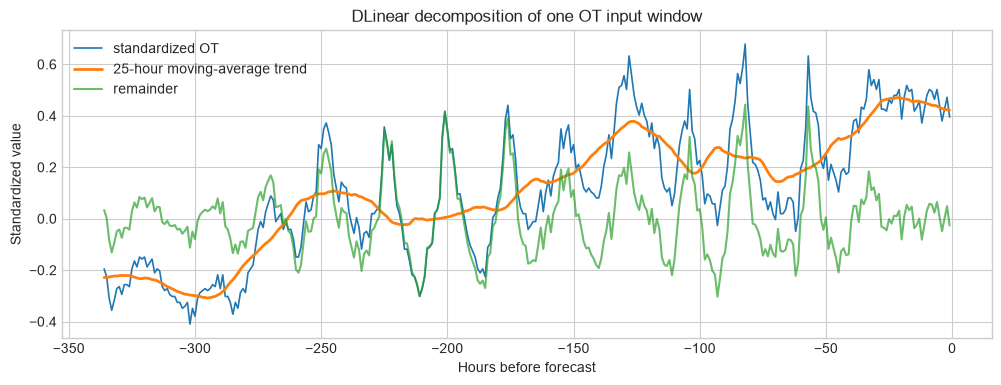

In [6]:
# Visualize what the fixed decomposition does to OT in one input window.
example_input, _ = datasets["validation"][0]
with torch.no_grad():
    remainder, trend = model.decomposition(example_input.unsqueeze(0))

ot_index = FEATURE_COLUMNS.index("OT")
hours = range(-input_length, 0)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hours, example_input[:, ot_index], label="standardized OT", linewidth=1.2)
ax.plot(hours, trend[0, :, ot_index], label="25-hour moving-average trend", linewidth=2)
ax.plot(hours, remainder[0, :, ot_index], label="remainder", alpha=0.7)
ax.set(title="DLinear decomposition of one OT input window", xlabel="Hours before forecast", ylabel="Standardized value")
ax.legend()
plt.show()

This is a moving-average decomposition, not a full statistical seasonal decomposition such as STL. The word “seasonal” in the implementation refers to everything left after removing the smooth trend.

## 6. Train using validation only

Each training batch minimizes MSE across every predicted hour and channel. At the end of each epoch we measure validation MSE. The best validation state is retained; three consecutive non-improving epochs trigger early stopping.

In [7]:
seed_everything(seed)
training_result = train_forecaster(
    model,
    loaders["train"],
    loaders["validation"],
    device=device,
    learning_rate=config["training"]["learning_rate"],
    max_epochs=config["training"]["max_epochs"],
    patience=config["training"]["early_stopping_patience"],
)

history = pd.DataFrame(training_result.history)
print(f"Best epoch: {training_result.best_epoch}")
print(f"Best validation MSE: {training_result.best_validation_mse:.6f}")
print(f"Stopped early: {training_result.stopped_early}")
history

Best epoch: 5
Best validation MSE: 0.646217
Stopped early: True


,epoch,learning_rate,train_mse,validation_mse
0,1,0.005000,0.399989,0.710503
1,2,0.002500,0.356265,0.692430
2,3,0.001250,0.342718,0.674927
3,4,0.000625,0.337121,0.662570
4,5,0.000313,0.334121,0.646217
5,6,0.000156,0.332403,0.650689
6,7,0.000078,0.331240,0.652341
7,8,0.000039,0.330677,0.654238


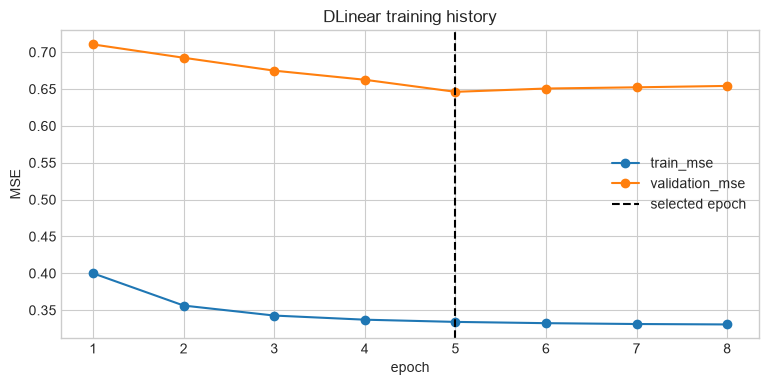

In [8]:
ax = history.plot(
    x="epoch",
    y=["train_mse", "validation_mse"],
    marker="o",
    figsize=(9, 4),
)
ax.axvline(training_result.best_epoch, color="black", linestyle="--", label="selected epoch")
ax.set(title="DLinear training history", ylabel="MSE")
ax.legend()
plt.show()

A lower training curve is expected. The important curve is validation: its minimum chooses the checkpoint. A large and growing train–validation gap would indicate overfitting or distribution shift.

## 7. Final test evaluation: naive forecasts versus DLinear

Only now do we evaluate the selected model on the test set. Every method receives exactly the same historical windows and is scored against exactly the same targets.

In [9]:
test_last, test_targets = collect_forecasts(
    loaders["test"],
    lambda history: last_value_forecast(history, prediction_length),
)
test_daily, _ = collect_forecasts(
    loaders["test"],
    lambda history: seasonal_naive_forecast(
        history, prediction_length, season_length=24
    ),
)

@torch.inference_mode()
def collect_model_forecasts(model, loader, device):
    model.eval()
    predictions, actuals = [], []
    for history, target in loader:
        predictions.append(model(history.to(device)).cpu())
        actuals.append(target)
    return torch.cat(predictions), torch.cat(actuals)


test_dlinear, _ = collect_model_forecasts(model, loaders["test"], device)
test_results = pd.DataFrame(
    {
        "Last value": metric_row(test_last, test_targets),
        "Daily seasonal naive": metric_row(test_daily, test_targets),
        "DLinear reconstruction": metric_row(test_dlinear, test_targets),
    }
).T
test_results

,MSE,MAE,RMSE
Last value,1.294371,0.713181,1.137704
Daily seasonal naive,0.512225,0.433303,0.715699
DLinear reconstruction,0.376917,0.400153,0.613936


The [official DLinear benchmark](https://github.com/cure-lab/LTSF-Linear/blob/main/LTSF-Benchmark.md) reports **MSE 0.375** and **MAE 0.399** for multivariate ETTh1 with input 336 and horizon 96. Exact equality is not required by the assignment. Differences can arise from software versions, GPU kernels, window conventions, random initialization, and the stricter choice not to inspect test loss during training.

In [10]:
paper_comparison = pd.DataFrame(
    {
        "MSE": [0.375, test_results.loc["DLinear reconstruction", "MSE"]],
        "MAE": [0.399, test_results.loc["DLinear reconstruction", "MAE"]],
    },
    index=["Official reported DLinear", "Our DLinear reconstruction"],
)
paper_comparison

,MSE,MAE
Official reported DLinear,0.375000,0.399000
Our DLinear reconstruction,0.376917,0.400153


## 8. Which variables are easiest to forecast?

The paper's headline metric averages all seven channels. Per-channel errors are additional diagnostics, not replacements for the official aggregate. They help us see whether OT behaves differently and later evaluate a cross-channel improvement.

In [11]:
per_channel = pd.DataFrame(
    {
        "MSE": [mse(test_dlinear[:, :, i], test_targets[:, :, i]).item() for i in range(len(FEATURE_COLUMNS))],
        "MAE": [mae(test_dlinear[:, :, i], test_targets[:, :, i]).item() for i in range(len(FEATURE_COLUMNS))],
        "RMSE": [rmse(test_dlinear[:, :, i], test_targets[:, :, i]).item() for i in range(len(FEATURE_COLUMNS))],
    },
    index=FEATURE_COLUMNS,
)
per_channel

,MSE,MAE,RMSE
HUFL,0.754627,0.587107,0.868693
HULL,0.211449,0.342929,0.459836
MUFL,0.779059,0.583088,0.882643
MULL,0.171522,0.298069,0.414152
LUFL,0.511380,0.497565,0.715108
LULL,0.122516,0.270338,0.350023
OT,0.087868,0.221974,0.296425


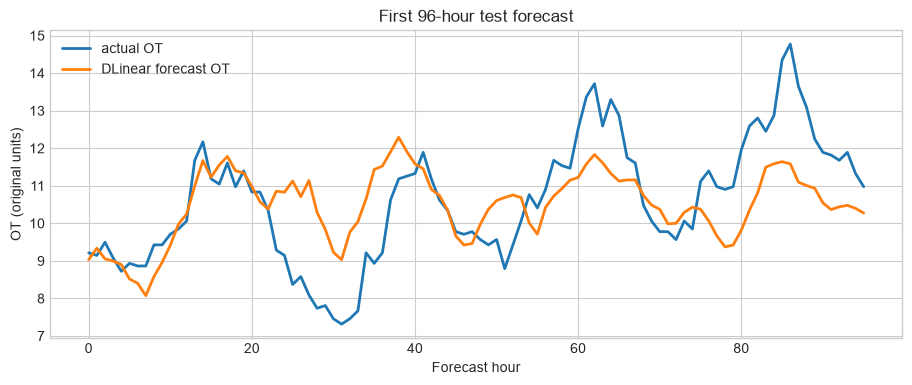

In [12]:
# Plot OT for the first test forecast window in original temperature units.
channel_mean = torch.tensor(data.scaler.mean_, dtype=torch.float32)
channel_scale = torch.tensor(data.scaler.scale_, dtype=torch.float32)
actual_original = test_targets[0] * channel_scale + channel_mean
forecast_original = test_dlinear[0] * channel_scale + channel_mean

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(actual_original[:, ot_index], label="actual OT", linewidth=2)
ax.plot(forecast_original[:, ot_index], label="DLinear forecast OT", linewidth=2)
ax.set(title="First 96-hour test forecast", xlabel="Forecast hour", ylabel="OT (original units)")
ax.legend()
plt.show()

## 9. Save the reproducible result

We save only compact artifacts needed for comparison: the resolved configuration, epoch history, and metrics. The notebook remains the readable explanation and the model can be regenerated from the fixed seed.

In [13]:
result_directory = (
    PROJECT_ROOT
    / "results"
    / "dlinear"
    / "reconstruction"
    / "etth1"
    / f"horizon_{prediction_length:03d}"
    / f"seed_{seed}"
)
result_directory.mkdir(parents=True, exist_ok=True)

with (result_directory / "config.yaml").open("w") as file:
    yaml.safe_dump(config, file, sort_keys=False)
history.to_csv(result_directory / "training_history.csv", index=False)

metrics_to_save = {
    method: {metric: float(value) for metric, value in row.items()}
    for method, row in test_results.to_dict(orient="index").items()
}
metrics_to_save["official_reported_dlinear"] = {"MSE": 0.375, "MAE": 0.399}
with (result_directory / "metrics.json").open("w") as file:
    json.dump(metrics_to_save, file, indent=2)

print("Saved compact results to:", result_directory.relative_to(PROJECT_ROOT))

Saved compact results to: results\dlinear\reconstruction\etth1\horizon_096\seed_2021


## 10. What this completes—and what comes next

For the 96-hour experiment, this notebook now covers the assignment's reconstruction requirements: method and objective, reproducible preprocessing, temporal evaluation, simple baselines, paper metrics, an additional metric, and comparison with the reported result.

Before calling DLinear reconstruction fully complete, we will review this run together and then repeat the same controlled experiment for horizons 192, 336, and 720. After that, the PatchTST reconstruction will use the same data splits and evaluation functions.